In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

In [3]:
data = pd.read_csv("games.csv")

In [4]:
cols_to_upper = ['Title', 'Team','Genres','Summary','Reviews']
for col in cols_to_upper:
    data[col] = data[col].str.upper()

In [5]:
column_to_clean = 'Genres'
data[column_to_clean] = data[column_to_clean].astype(str).str.replace('[','').str.replace(']','').str.replace(',','').str.replace("'","").str.replace('"','')
column_to_clean = 'Team'
data[column_to_clean] = data[column_to_clean].astype(str).str.replace('[','').str.replace(']','').str.replace(',','').str.replace("'","").str.replace('"','')
column_to_clean = 'Reviews'
data[column_to_clean] = data[column_to_clean].astype(str).str.replace('[','').str.replace(']','').str.replace(',','').str.replace("'","").str.replace('"','')

In [6]:
def convert_K_to_thousands(value):
    if isinstance(value, str) and 'K' in value:
                return float(value.replace('K', '')) * 1000
    else:
                return value
data['Times Listed'] = data['Times Listed'].apply(convert_K_to_thousands)
data['Number of Reviews'] = data['Number of Reviews'].apply(convert_K_to_thousands)
data['Plays'] = data['Plays'].apply(convert_K_to_thousands)
data['Playing'] = data['Playing'].apply(convert_K_to_thousands)
data['Backlogs'] = data['Backlogs'].apply(convert_K_to_thousands)
data['Wishlist'] = data['Wishlist'].apply(convert_K_to_thousands)

In [7]:
data['Release Date'] = pd.to_datetime(data['Release Date'], errors='coerce')

In [8]:
data['Release Date'] = pd.to_datetime(data['Release Date'], errors='coerce')
data['Year'] = data['Release Date'].dt.year

In [9]:
games_per_year = data.groupby('Year')['Title'].count().reset_index()
games_per_year.columns = ['Year', 'Total_Years']

In [10]:
data = data.merge(games_per_year, on='Year', how='left')

In [169]:
data

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist,Year,Total_Years
0,0,ELDEN RING,2022-02-25,BANDAI NAMCO ENTERTAINMENT FROMSOFTWARE,4.5,3900.0,3900.0,ADVENTURE RPG,"ELDEN RING IS A FANTASY, ACTION AND OPEN WORLD...",THE FIRST PLAYTHROUGH OF ELDEN RING IS ONE OF ...,17000.0,3800.0,4600.0,4800.0,2022.0,132.0
1,1,HADES,2019-12-10,SUPERGIANT GAMES,4.3,2900.0,2900.0,ADVENTURE BRAWLER INDIE RPG,A ROGUE-LITE HACK AND SLASH DUNGEON CRAWLER IN...,CONVINCED THIS IS A ROGUELIKE FOR PEOPLE WHO D...,21000.0,3200.0,6300.0,3600.0,2019.0,87.0
2,2,THE LEGEND OF ZELDA: BREATH OF THE WILD,2017-03-03,NINTENDO NINTENDO EPD PRODUCTION GROUP NO. 3,4.4,4300.0,4300.0,ADVENTURE RPG,THE LEGEND OF ZELDA: BREATH OF THE WILD IS THE...,THIS GAME IS THE GAME (THAT IS NOT CS:GO) THAT...,30000.0,2500.0,5000.0,2600.0,2017.0,70.0
3,3,UNDERTALE,2015-09-15,TOBYFOX 8-4,4.2,3500.0,3500.0,ADVENTURE INDIE RPG TURN BASED STRATEGY,"A SMALL CHILD FALLS INTO THE UNDERGROUND, WHER...",SOUNDTRACK IS TIED FOR #1 WITH NIER AUTOMATA. ...,28000.0,679,4900.0,1800.0,2015.0,73.0
4,4,HOLLOW KNIGHT,2017-02-24,TEAM CHERRY,4.4,3000.0,3000.0,ADVENTURE INDIE PLATFORM,A 2D METROIDVANIA WITH AN EMPHASIS ON CLOSE CO...,THIS GAMES WORLDBUILDING IS INCREDIBLE WITH IT...,21000.0,2400.0,8300.0,2300.0,2017.0,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,1507,BACK TO THE FUTURE: THE GAME,2010-12-22,TELLTALE GAMES,3.2,94,94,ADVENTURE POINT-AND-CLICK,BACK TO THE FUTURE: THE GAME IS ONE OF TELLTAL...,VERY ENJOYABLE GAME. THE STORY ADDS ONTO THE M...,763,5,223,67,2010.0,58.0
1508,1508,TEAM SONIC RACING,2019-05-21,SUMO DIGITAL SEGA,2.9,264,264,ARCADE RACING,TEAM SONIC RACING COMBINES THE BEST ELEMENTS O...,JOGO MORTO MAS BOM NOT MY CUP OF TEA COMPARED ...,1500.0,49,413,107,2019.0,87.0
1509,1509,DRAGON'S DOGMA,2012-05-22,CAPCOM,3.7,210,210,BRAWLER RPG,"SET IN A HUGE OPEN WORLD, DRAGON’S DOGMA: DARK...",UNDERRATED. A GRANDES RASGOS ES COMO UN MMO PE...,1100.0,45,487,206,2012.0,60.0
1510,1510,BALDUR'S GATE 3,2020-10-06,LARIAN STUDIOS,4.1,165,165,ADVENTURE RPG STRATEGY TACTICAL TURN BASED STR...,"AN ANCIENT EVIL HAS RETURNED TO BALDUR'S GATE,...",BU TÜRE BU OYUNLA GIRMEYE ÇALIŞMAK HATAYDI SAN...,269,79,388,602,2020.0,74.0


In [11]:
data.groupby('Year')['Title'].count()

Year
1980.0      1
1982.0      1
1985.0      1
1986.0      4
1987.0      3
1988.0      5
1989.0      5
1990.0      6
1991.0     11
1992.0      6
1993.0     12
1994.0     11
1995.0     12
1996.0     15
1997.0     18
1998.0     16
1999.0     25
2000.0     15
2001.0     30
2002.0     22
2003.0     26
2004.0     37
2005.0     41
2006.0     32
2007.0     50
2008.0     44
2009.0     40
2010.0     58
2011.0     50
2012.0     60
2013.0     68
2014.0     59
2015.0     73
2016.0     75
2017.0     70
2018.0     77
2019.0     87
2020.0     74
2021.0     97
2022.0    132
2023.0     38
2024.0      1
2025.0      1
Name: Title, dtype: int64

# Duplicates

In [12]:
data[data.duplicated()]

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist,Year,Total_Years


In [15]:
numeric_sum = data[data.duplicated()].select_dtypes(include=['number']).sum()

In [14]:
data.isnull().sum()

Unnamed: 0            0
Title                 0
Release Date          3
Team                  0
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
Year                  3
Total_Years           3
dtype: int64

# Null Values

<Axes: >

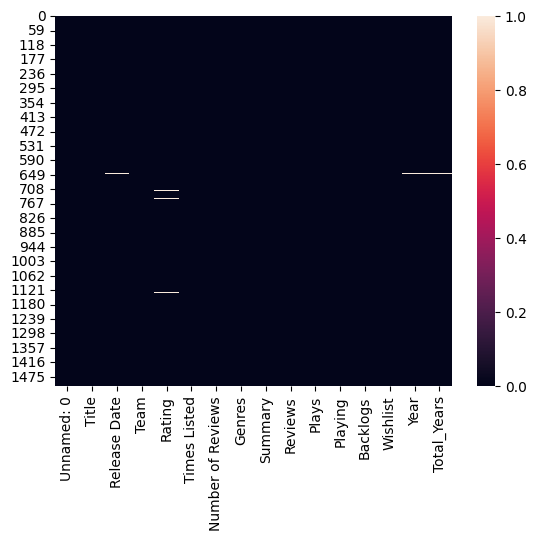

In [16]:
sns.heatmap(data.isnull())

In [17]:
data_cat=data.select_dtypes("object")
data_num=data.select_dtypes("number")

In [19]:
for i in data_num.columns:
    median = data_num[i].median()
    data_num[i] = data_num[i].fillna(median)

In [20]:
data_num.isnull().sum()

Unnamed: 0     0
Rating         0
Year           0
Total_Years    0
dtype: int64

<Axes: >

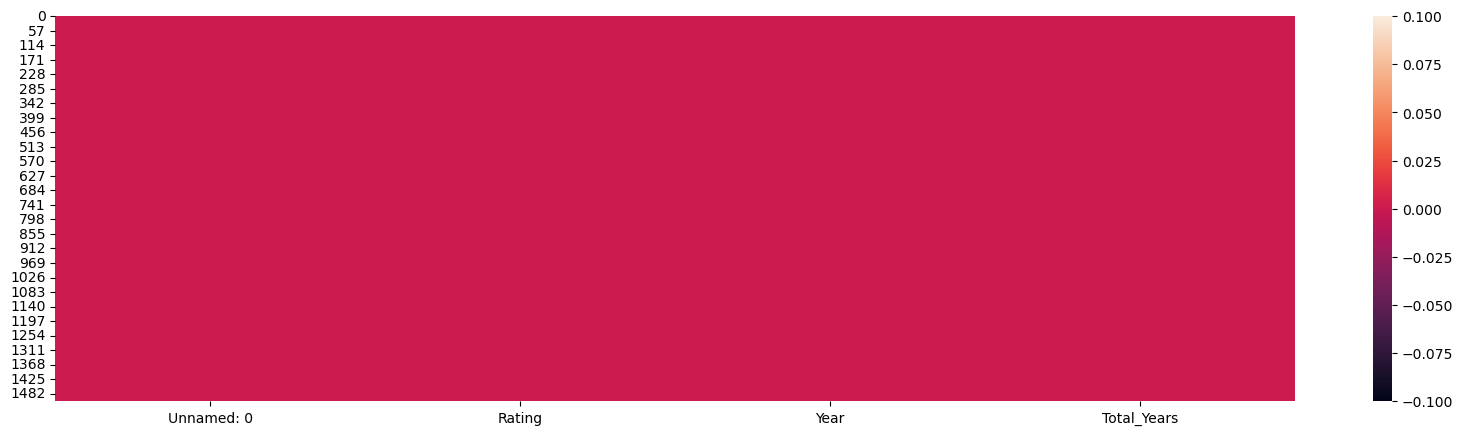

In [179]:
plt.figure(figsize=(20,5))
sns.heatmap(data_num.isnull())

In [21]:
for i in data_cat.columns:
    mode = data_cat[i].mode()[0]
    data_cat[i] = data_cat[i].fillna(mode)

<Axes: >

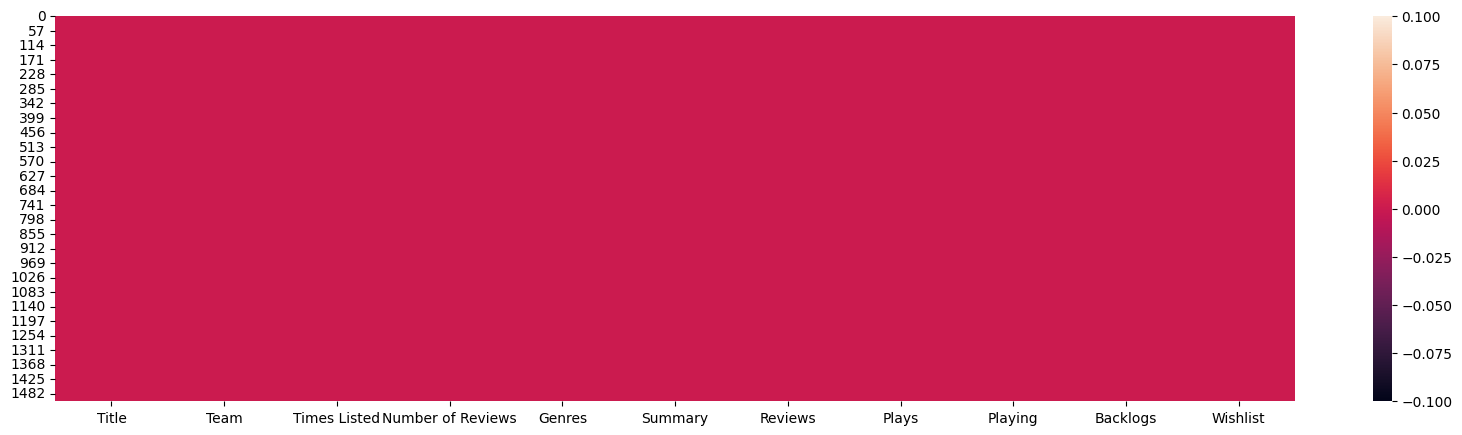

In [22]:
plt.figure(figsize=(20,5))
sns.heatmap(data_cat.isnull())

In [23]:
data_cat.isna().sum()

Title                0
Team                 0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
dtype: int64

In [28]:
import sys
print(sys.executable)

c:\Users\nj181\AppData\Local\Programs\Python\Python313\python.exe


In [32]:
!pip install openpyxl


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import openpyxl

In [34]:
data.to_excel('R_Game_Data.xlsx', index=False)

In [25]:
data.to_csv('R_Game_Data.csv', index=False)

In [36]:
data2 = pd.read_csv("vgsales.csv")

In [186]:
cols_to_upper = ['Name', 'Genre','Publisher']
for col in cols_to_upper:
    data2[col] = data2[col].str.upper()

In [187]:
data2

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,WII SPORTS,Wii,2006.0,SPORTS,NINTENDO,41.49,29.02,3.77,8.46,82.74
1,2,SUPER MARIO BROS.,NES,1985.0,PLATFORM,NINTENDO,29.08,3.58,6.81,0.77,40.24
2,3,MARIO KART WII,Wii,2008.0,RACING,NINTENDO,15.85,12.88,3.79,3.31,35.82
3,4,WII SPORTS RESORT,Wii,2009.0,SPORTS,NINTENDO,15.75,11.01,3.28,2.96,33.00
4,5,POKEMON RED/POKEMON BLUE,GB,1996.0,ROLE-PLAYING,NINTENDO,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,WOODY WOODPECKER IN CRAZY CASTLE 5,GBA,2002.0,PLATFORM,KEMCO,0.01,0.00,0.00,0.00,0.01
16594,16597,MEN IN BLACK II: ALIEN ESCAPE,GC,2003.0,SHOOTER,INFOGRAMES,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE INTERNATIONAL BAJA 1000: THE OFFICIAL GAME,PS2,2008.0,RACING,ACTIVISION,0.00,0.00,0.00,0.00,0.01
16596,16599,KNOW HOW 2,DS,2010.0,PUZZLE,7G//AMES,0.00,0.01,0.00,0.00,0.01


# Duplicates

In [37]:
data2[data2.duplicated()]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales


In [38]:
data2[data2.duplicated()].sum()

Rank              0
Name              0
Platform          0
Year            0.0
Genre             0
Publisher         0
NA_Sales        0.0
EU_Sales        0.0
JP_Sales        0.0
Other_Sales     0.0
Global_Sales    0.0
dtype: object

In [39]:
data2.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

<Axes: >

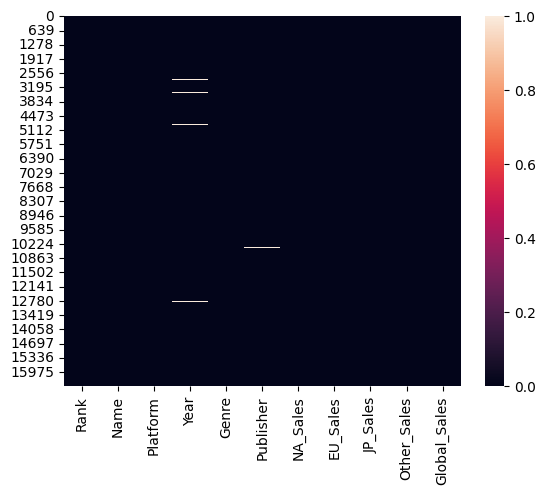

In [40]:
sns.heatmap(data2.isnull())

In [41]:
#data2.rename(columns={'Genre': 'Genres'}, inplace=True)

In [42]:
data2_cat=data.select_dtypes("object")
data2_num=data.select_dtypes("number")

In [43]:
for i in data2_num.columns:
    median = data2_num[i].median()
    data2_num[i] = data2_num[i].fillna(median)

In [44]:
for i in data2_cat.columns:
    mode = data2_cat[i].mode()[0]
    data2_cat[i] = data2_cat[i].fillna(mode)

In [45]:
data2.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [46]:
#plt.figure(figsize=(20,5))
#sns.heatmap(data2_cat.isnull())

In [47]:
data2_num.isna().sum()

Unnamed: 0     0
Rating         0
Year           0
Total_Years    0
dtype: int64

In [48]:
data.rename(columns={'Title': 'Name'}, inplace=True)

In [49]:
column_headers = list(data.columns),list(data2.columns)
#column_headers

In [50]:
data2.to_excel('R_Sales_Data.xlsx', index=False)

In [51]:
data2.to_csv('R_Sale_Data.csv', index=False)

In [52]:
VGame_Data = pd.merge(data, data2, on='Name',how = 'inner')

In [53]:
VGame_Data[VGame_Data.duplicated()]

,Unnamed: 0,Name,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,...,Rank,Platform,Year_y,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales


In [54]:
VGame_Data[VGame_Data.duplicated()].select_dtypes(include=['number']).sum()

Unnamed: 0      0.0
Rating          0.0
Year_x          0.0
Total_Years     0.0
Rank            0.0
Year_y          0.0
NA_Sales        0.0
EU_Sales        0.0
JP_Sales        0.0
Other_Sales     0.0
Global_Sales    0.0
dtype: float64

In [55]:
VGame_Data.isnull().sum()

Unnamed: 0           0
Name                 0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
Year_x               0
Total_Years          0
Rank                 0
Platform             0
Year_y               0
Genre                0
Publisher            0
NA_Sales             0
EU_Sales             0
JP_Sales             0
Other_Sales          0
Global_Sales         0
dtype: int64

In [56]:
VGame_Data['Year_y'].fillna(VGame_Data['Year_y'].median(), inplace=True)
VGame_Data['Publisher'].fillna('unknown', inplace=True)

In [57]:
VGame_Data.isnull().sum()

Unnamed: 0           0
Name                 0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
Year_x               0
Total_Years          0
Rank                 0
Platform             0
Year_y               0
Genre                0
Publisher            0
NA_Sales             0
EU_Sales             0
JP_Sales             0
Other_Sales          0
Global_Sales         0
dtype: int64

In [79]:
VGame_Data_cat=VGame_Data.select_dtypes("object")
VGame_Data_num=VGame_Data.select_dtypes("number")

In [80]:
for i in VGame_Data_num.columns:
    median = VGame_Data_num[i].median()
    VGame_Data_num[i] = VGame_Data_num[i].fillna(median)

In [81]:
for i in VGame_Data_cat.columns:
    mode = VGame_Data_cat[i].mode()[0]
    VGame_Data_cat[i] = VGame_Data_cat[i].fillna(mode)

In [82]:
VGame_Data.isnull().sum()

Unnamed: 0           0
Name                 0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
Year_x               0
Total_Years          0
Rank                 0
Platform             0
Year_y               0
Genre                0
Publisher            0
NA_Sales             0
EU_Sales             0
JP_Sales             0
Other_Sales          0
Global_Sales         0
dtype: int64

In [83]:
VGame_Data.to_excel('VGame_Data.xlsx', index=False)

In [84]:
VGame_Data.to_csv('VGame_Data.csv', index=False)

In [64]:
VGame_Data

,Unnamed: 0,Name,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,...,Rank,Platform,Year_y,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,577,F.E.A.R.,2005-10-17,MONOLITH PRODUCTIONS VIVENDI UNIVERSAL,3.8,564,564,SHOOTER,F.E.A.R. IS A HORROR FPS THAT RESEMBLES A CROS...,SHUT YUOR FUCKING MOUTH (PLAYED BEFORE 2023)\N...,...,3656,PS3,2007.0,Shooter,Vivendi Games,0.18,0.27,0.00,0.10,0.55
1,577,F.E.A.R.,2005-10-17,MONOLITH PRODUCTIONS VIVENDI UNIVERSAL,3.8,564,564,SHOOTER,F.E.A.R. IS A HORROR FPS THAT RESEMBLES A CROS...,SHUT YUOR FUCKING MOUTH (PLAYED BEFORE 2023)\N...,...,5366,X360,2006.0,Shooter,Vivendi Games,0.28,0.03,0.00,0.03,0.34
2,1016,ICO,2001-09-24,TEAM ICO SONY COMPUTER ENTERTAINMENT INC. (SCEI),4.0,671,671,ADVENTURE PLATFORM PUZZLE,AN ACTION-ADVENTURE GAME IN WHICH A BOY IS ABA...,SIMILAR TO SHADOW THE COLASSES THE MINIMAL NAT...,...,4168,PS2,2001.0,Action,Sony Computer Entertainment,0.23,0.18,0.00,0.06,0.47
3,1016,ICO,2001-09-24,TEAM ICO SONY COMPUTER ENTERTAINMENT INC. (SCEI),4.0,671,671,ADVENTURE PLATFORM PUZZLE,AN ACTION-ADVENTURE GAME IN WHICH A BOY IS ABA...,SIMILAR TO SHADOW THE COLASSES THE MINIMAL NAT...,...,12499,PS3,2011.0,Action,Sony Computer Entertainment,0.00,0.00,0.06,0.00,0.06
4,1463,FIFA 14,2013-09-24,EA SPORTS EA CANADA,3.2,92,92,SPORT,FIFA 14 IS A 2013 SPORTS ASSOCIATION FOOTBALL ...,IF YOU LIKE PLAYING WITH BALLS BUDDY DO I HAVE...,...,113,PS3,2013.0,Sports,Electronic Arts,0.78,4.32,0.07,1.73,6.90
5,1463,FIFA 14,2013-09-24,EA SPORTS EA CANADA,3.2,92,92,SPORT,FIFA 14 IS A 2013 SPORTS ASSOCIATION FOOTBALL ...,IF YOU LIKE PLAYING WITH BALLS BUDDY DO I HAVE...,...,257,X360,2013.0,Sports,Electronic Arts,0.92,2.93,0.01,0.46,4.31
6,1463,FIFA 14,2013-09-24,EA SPORTS EA CANADA,3.2,92,92,SPORT,FIFA 14 IS A 2013 SPORTS ASSOCIATION FOOTBALL ...,IF YOU LIKE PLAYING WITH BALLS BUDDY DO I HAVE...,...,494,PS4,2013.0,Sports,Electronic Arts,0.61,1.85,0.11,0.33,2.90
7,1463,FIFA 14,2013-09-24,EA SPORTS EA CANADA,3.2,92,92,SPORT,FIFA 14 IS A 2013 SPORTS ASSOCIATION FOOTBALL ...,IF YOU LIKE PLAYING WITH BALLS BUDDY DO I HAVE...,...,1700,XOne,2013.0,Sports,Electronic Arts,0.41,0.66,0.00,0.12,1.19
8,1463,FIFA 14,2013-09-24,EA SPORTS EA CANADA,3.2,92,92,SPORT,FIFA 14 IS A 2013 SPORTS ASSOCIATION FOOTBALL ...,IF YOU LIKE PLAYING WITH BALLS BUDDY DO I HAVE...,...,3990,PSV,2013.0,Sports,Electronic Arts,0.11,0.25,0.01,0.13,0.50
9,1463,FIFA 14,2013-09-24,EA SPORTS EA CANADA,3.2,92,92,SPORT,FIFA 14 IS A 2013 SPORTS ASSOCIATION FOOTBALL ...,IF YOU LIKE PLAYING WITH BALLS BUDDY DO I HAVE...,...,4505,PC,2013.0,Sports,Electronic Arts,0.01,0.36,0.00,0.06,0.43


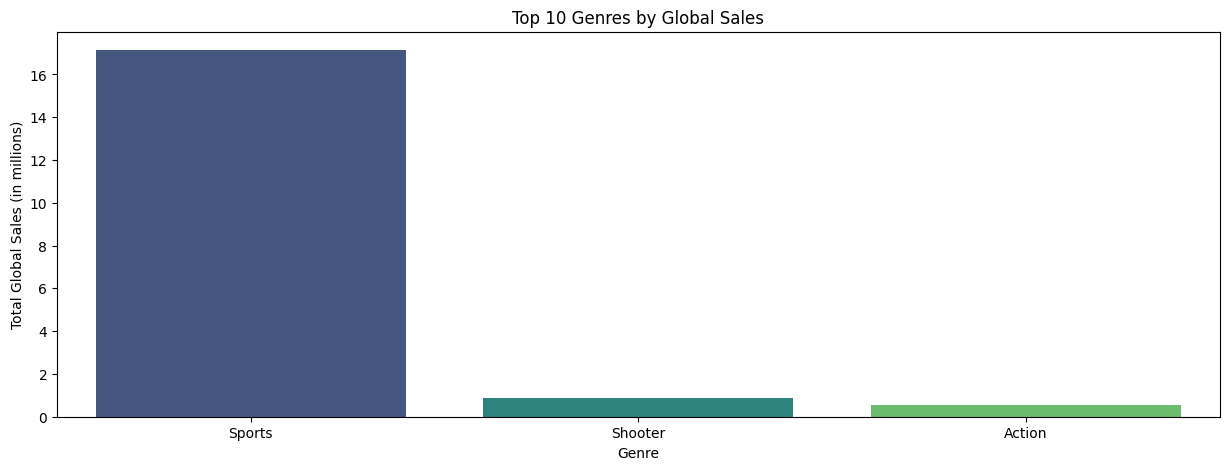

In [85]:
top_genres = VGame_Data.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(15,5))
sns.barplot(x=top_genres.index, y=top_genres.values, palette="viridis")
plt.title("Top 10 Genres by Global Sales")
plt.xlabel("Genre")
plt.ylabel("Total Global Sales (in millions)")
plt.show()

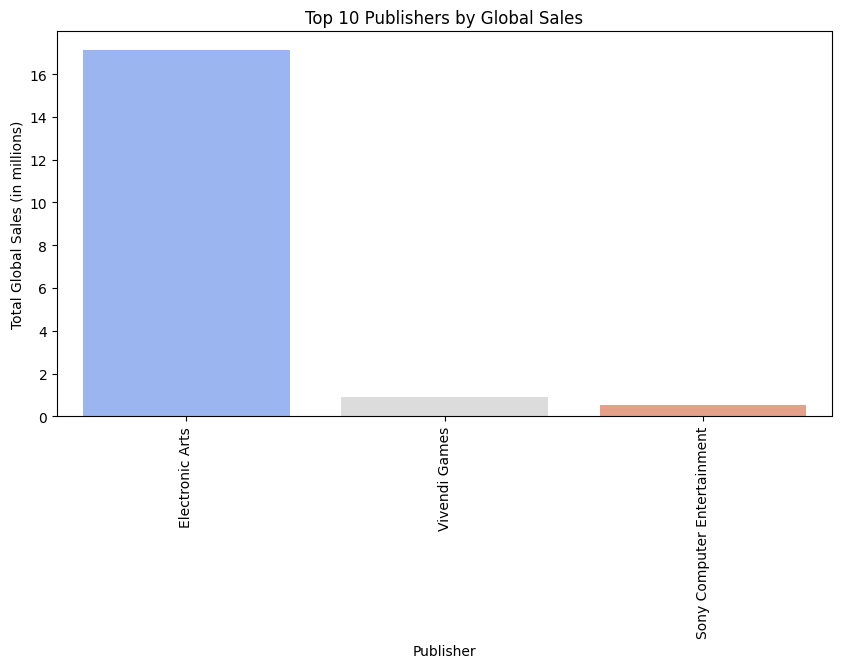

In [86]:
top_publishers = VGame_Data.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=top_publishers.index, y=top_publishers.values, palette="coolwarm")
plt.title("Top 10 Publishers by Global Sales")
plt.xlabel("Publisher")
plt.ylabel("Total Global Sales (in millions)")
plt.xticks(rotation=90)
plt.show()

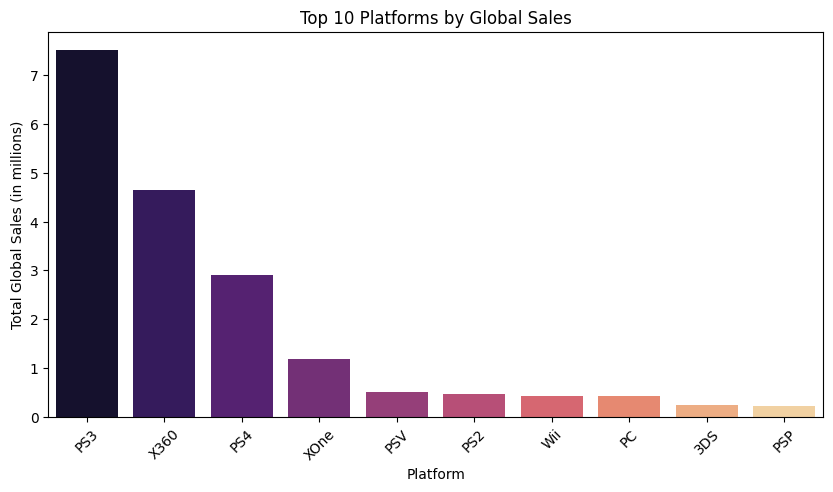

In [87]:
top_platforms = VGame_Data.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=top_platforms.index, y=top_platforms.values, palette="magma")
plt.title("Top 10 Platforms by Global Sales")
plt.xlabel("Platform")
plt.ylabel("Total Global Sales (in millions)")
plt.xticks(rotation=45)
plt.show()

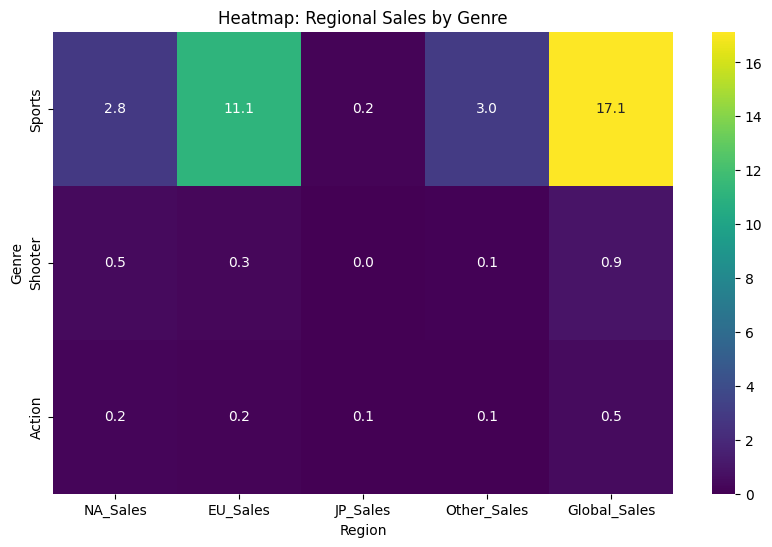

In [88]:
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

genre_sales = VGame_Data.groupby("Genre")[sales_cols].sum().sort_values("Global_Sales", ascending=False)

plt.figure(figsize=(10,6))
sns.heatmap(genre_sales, annot=True, fmt=".1f", cmap="viridis")
plt.title("Heatmap: Regional Sales by Genre")
plt.xlabel("Region")
plt.ylabel("Genre")
plt.show()

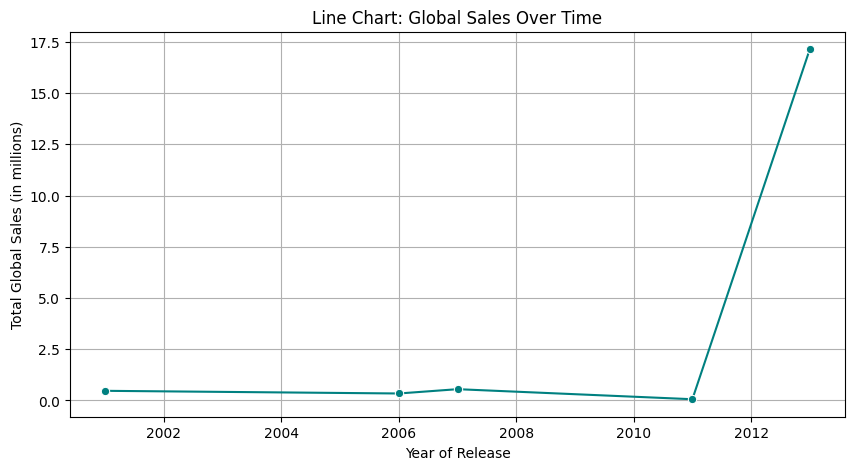

In [89]:
sales_trend = VGame_Data.groupby("Year_y")["Global_Sales"].sum().reset_index()

# Plot line chart
plt.figure(figsize=(10,5))
sns.lineplot(x="Year_y", y="Global_Sales", data=sales_trend, marker="o", color="teal")
plt.title("Line Chart: Global Sales Over Time")
plt.xlabel("Year of Release")
plt.ylabel("Total Global Sales (in millions)")
plt.grid(True)
plt.show()

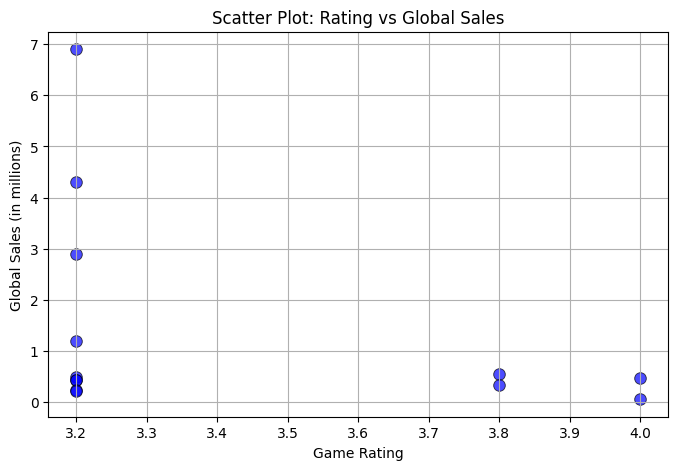

In [90]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Rating", y="Global_Sales", data=VGame_Data, color="blue", s=70, alpha=0.7, edgecolor="black")

plt.title("Scatter Plot: Rating vs Global Sales")
plt.xlabel("Game Rating")
plt.ylabel("Global Sales (in millions)")
plt.grid(True)
plt.show()

In [91]:
R_Game_Data = pd.read_csv("R_Game_Data.csv")

In [92]:
R_Game_Data

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist,Year,Total_Years
0,0,ELDEN RING,2022-02-25,BANDAI NAMCO ENTERTAINMENT FROMSOFTWARE,4.5,3900.0,3900.0,ADVENTURE RPG,"ELDEN RING IS A FANTASY, ACTION AND OPEN WORLD...",THE FIRST PLAYTHROUGH OF ELDEN RING IS ONE OF ...,17000.0,3800.0,4600.0,4800.0,2022.0,132.0
1,1,HADES,2019-12-10,SUPERGIANT GAMES,4.3,2900.0,2900.0,ADVENTURE BRAWLER INDIE RPG,A ROGUE-LITE HACK AND SLASH DUNGEON CRAWLER IN...,CONVINCED THIS IS A ROGUELIKE FOR PEOPLE WHO D...,21000.0,3200.0,6300.0,3600.0,2019.0,87.0
2,2,THE LEGEND OF ZELDA: BREATH OF THE WILD,2017-03-03,NINTENDO NINTENDO EPD PRODUCTION GROUP NO. 3,4.4,4300.0,4300.0,ADVENTURE RPG,THE LEGEND OF ZELDA: BREATH OF THE WILD IS THE...,THIS GAME IS THE GAME (THAT IS NOT CS:GO) THAT...,30000.0,2500.0,5000.0,2600.0,2017.0,70.0
3,3,UNDERTALE,2015-09-15,TOBYFOX 8-4,4.2,3500.0,3500.0,ADVENTURE INDIE RPG TURN BASED STRATEGY,"A SMALL CHILD FALLS INTO THE UNDERGROUND, WHER...",SOUNDTRACK IS TIED FOR #1 WITH NIER AUTOMATA. ...,28000.0,679.0,4900.0,1800.0,2015.0,73.0
4,4,HOLLOW KNIGHT,2017-02-24,TEAM CHERRY,4.4,3000.0,3000.0,ADVENTURE INDIE PLATFORM,A 2D METROIDVANIA WITH AN EMPHASIS ON CLOSE CO...,THIS GAMES WORLDBUILDING IS INCREDIBLE WITH IT...,21000.0,2400.0,8300.0,2300.0,2017.0,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,1507,BACK TO THE FUTURE: THE GAME,2010-12-22,TELLTALE GAMES,3.2,94.0,94.0,ADVENTURE POINT-AND-CLICK,BACK TO THE FUTURE: THE GAME IS ONE OF TELLTAL...,VERY ENJOYABLE GAME. THE STORY ADDS ONTO THE M...,763.0,5.0,223.0,67.0,2010.0,58.0
1508,1508,TEAM SONIC RACING,2019-05-21,SUMO DIGITAL SEGA,2.9,264.0,264.0,ARCADE RACING,TEAM SONIC RACING COMBINES THE BEST ELEMENTS O...,JOGO MORTO MAS BOM NOT MY CUP OF TEA COMPARED ...,1500.0,49.0,413.0,107.0,2019.0,87.0
1509,1509,DRAGON'S DOGMA,2012-05-22,CAPCOM,3.7,210.0,210.0,BRAWLER RPG,"SET IN A HUGE OPEN WORLD, DRAGON’S DOGMA: DARK...",UNDERRATED. A GRANDES RASGOS ES COMO UN MMO PE...,1100.0,45.0,487.0,206.0,2012.0,60.0
1510,1510,BALDUR'S GATE 3,2020-10-06,LARIAN STUDIOS,4.1,165.0,165.0,ADVENTURE RPG STRATEGY TACTICAL TURN BASED STR...,"AN ANCIENT EVIL HAS RETURNED TO BALDUR'S GATE,...",BU TÜRE BU OYUNLA GIRMEYE ÇALIŞMAK HATAYDI SAN...,269.0,79.0,388.0,602.0,2020.0,74.0


🎮 Top 10 Highest Rated Games:

                                           Title  Rating  Number of Reviews
1252           ELDEN RING: SHADOW OF THE ERDTREE     4.8               18.0
28                  DISCO ELYSIUM: THE FINAL CUT     4.6             1100.0
1138                             HALF-LIFE: ALYX     4.6              515.0
43                                   OUTER WILDS     4.6             1800.0
1286                                 TOKYO NECRO     4.6               21.0
1198  METAL GEAR SOLID 3: SNAKE EATER HD EDITION     4.6              293.0
1322        BLOODBORNE: GAME OF THE YEAR EDITION     4.6              238.0
1104    SEKIRO: SHADOWS DIE TWICE - GOTY EDITION     4.6              173.0
1073           FINAL FANTASY XIV: SHADOWBRINGERS     4.6              401.0
1090           THE GREAT ACE ATTORNEY 2: RESOLVE     4.6              386.0


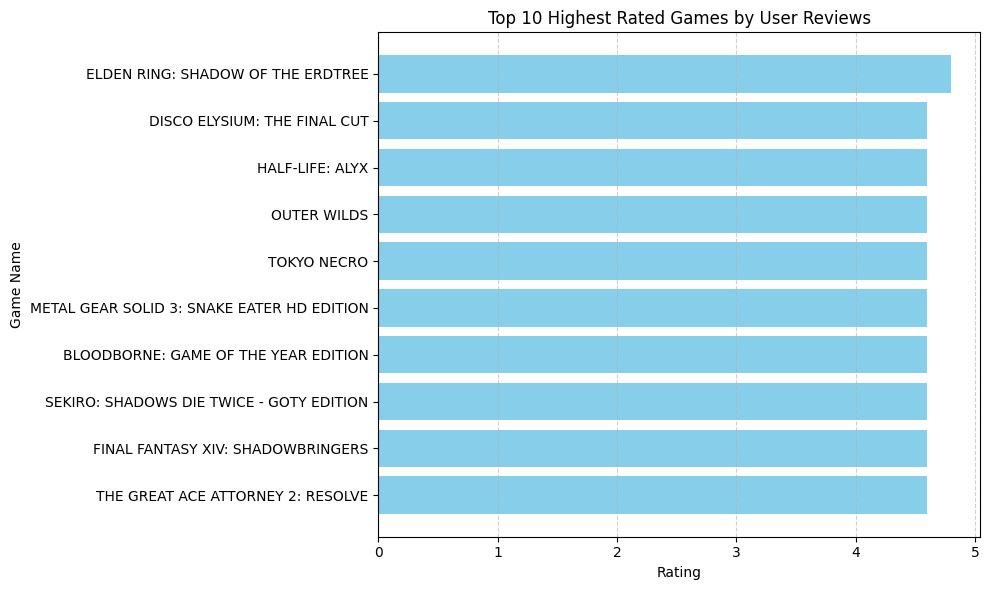

In [93]:
R_Game_Data["Rating"] = R_Game_Data["Rating"].astype(float)
top_rated_games = R_Game_Data.sort_values(by="Rating", ascending=False)[
    ["Title", "Rating", "Number of Reviews"]
].head(10)
print("🎮 Top 10 Highest Rated Games:\n")
print(top_rated_games)
plt.figure(figsize=(10, 6))
plt.barh(top_rated_games["Title"], top_rated_games["Rating"], color='skyblue')
plt.xlabel("Rating")
plt.ylabel("Game Name")
plt.title("Top 10 Highest Rated Games by User Reviews")
plt.gca().invert_yaxis()  # Highest rating on top
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

🎮 Top 10 Highest Rated Games:

                                           Title  Rating  Number of Reviews
1252           ELDEN RING: SHADOW OF THE ERDTREE     4.8               18.0
28                  DISCO ELYSIUM: THE FINAL CUT     4.6             1100.0
1138                             HALF-LIFE: ALYX     4.6              515.0
43                                   OUTER WILDS     4.6             1800.0
1286                                 TOKYO NECRO     4.6               21.0
1198  METAL GEAR SOLID 3: SNAKE EATER HD EDITION     4.6              293.0
1322        BLOODBORNE: GAME OF THE YEAR EDITION     4.6              238.0
1104    SEKIRO: SHADOWS DIE TWICE - GOTY EDITION     4.6              173.0
1073           FINAL FANTASY XIV: SHADOWBRINGERS     4.6              401.0
1090           THE GREAT ACE ATTORNEY 2: RESOLVE     4.6              386.0


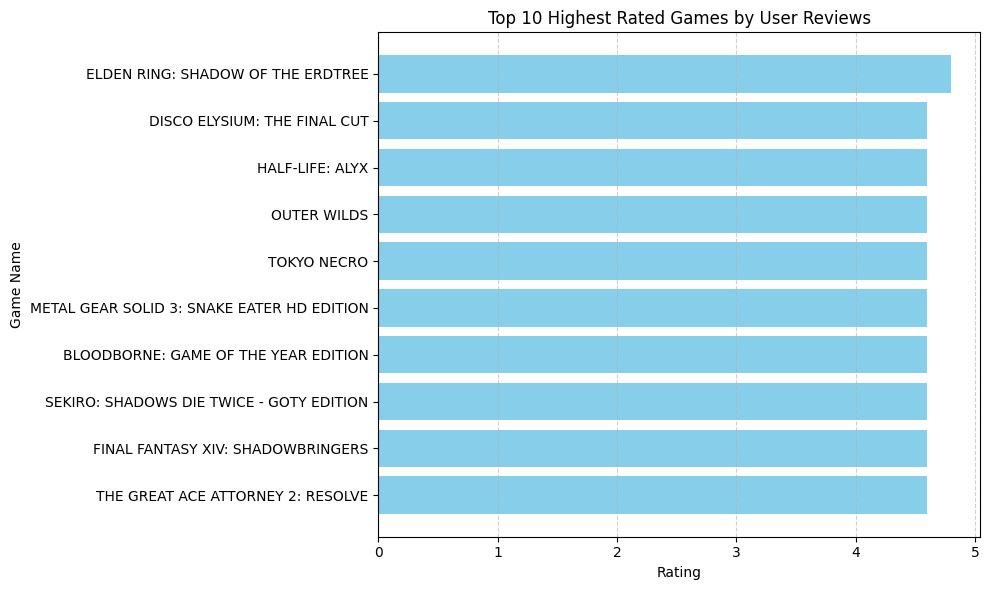

In [94]:
R_Game_Data["Rating"] = R_Game_Data["Rating"].astype(float)
top_rated_games = R_Game_Data.sort_values(by="Rating", ascending=False)[
    ["Title", "Rating", "Number of Reviews"]
].head(10) 

print("🎮 Top 10 Highest Rated Games:\n")
print(top_rated_games)

plt.figure(figsize=(10, 6))
plt.barh(top_rated_games["Title"], top_rated_games["Rating"], color='skyblue')
plt.xlabel("Rating")
plt.ylabel("Game Name")
plt.title("Top 10 Highest Rated Games by User Reviews")
plt.gca().invert_yaxis()  # Highest rating on top
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

🎮 Top 10 Games with Most Reviews:

                                       Title  Rating  Number of Reviews
2    THE LEGEND OF ZELDA: BREATH OF THE WILD     4.4             4300.0
328  THE LEGEND OF ZELDA: BREATH OF THE WILD     4.4             4300.0
778  THE LEGEND OF ZELDA: BREATH OF THE WILD     4.4             4300.0
776                               ELDEN RING     4.5             3900.0
326                               ELDEN RING     4.5             3900.0
0                                 ELDEN RING     4.5             3900.0
779                                UNDERTALE     4.2             3500.0
3                                  UNDERTALE     4.2             3500.0
329                                UNDERTALE     4.2             3500.0
340                               BLOODBORNE     4.5             3400.0


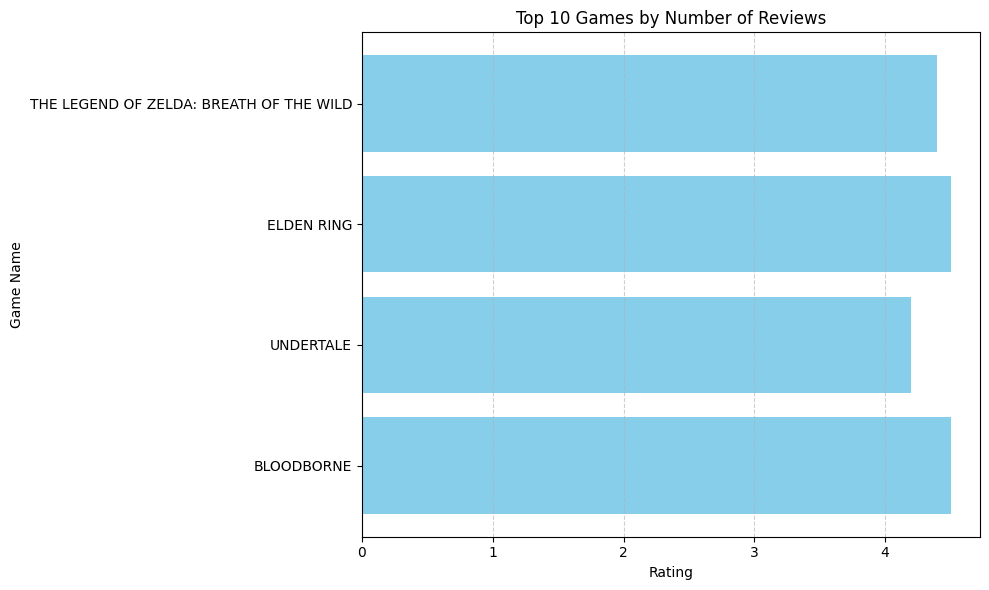

In [95]:
R_Game_Data["Rating"] = R_Game_Data["Rating"].astype(float)
R_Game_Data["Number of Reviews"] = R_Game_Data["Number of Reviews"].astype(float)
top_rated_games = R_Game_Data.sort_values(by="Number of Reviews", ascending=False)[
    ["Title", "Rating", "Number of Reviews"]
].head(10) 
print("🎮 Top 10 Games with Most Reviews:\n")
print(top_rated_games)
plt.figure(figsize=(10, 6))
plt.barh(top_rated_games["Title"], top_rated_games["Rating"], color='skyblue')
plt.xlabel("Rating")
plt.ylabel("Game Name")
plt.title("Top 10 Games by Number of Reviews")
plt.gca().invert_yaxis()  # Highest rating on top
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

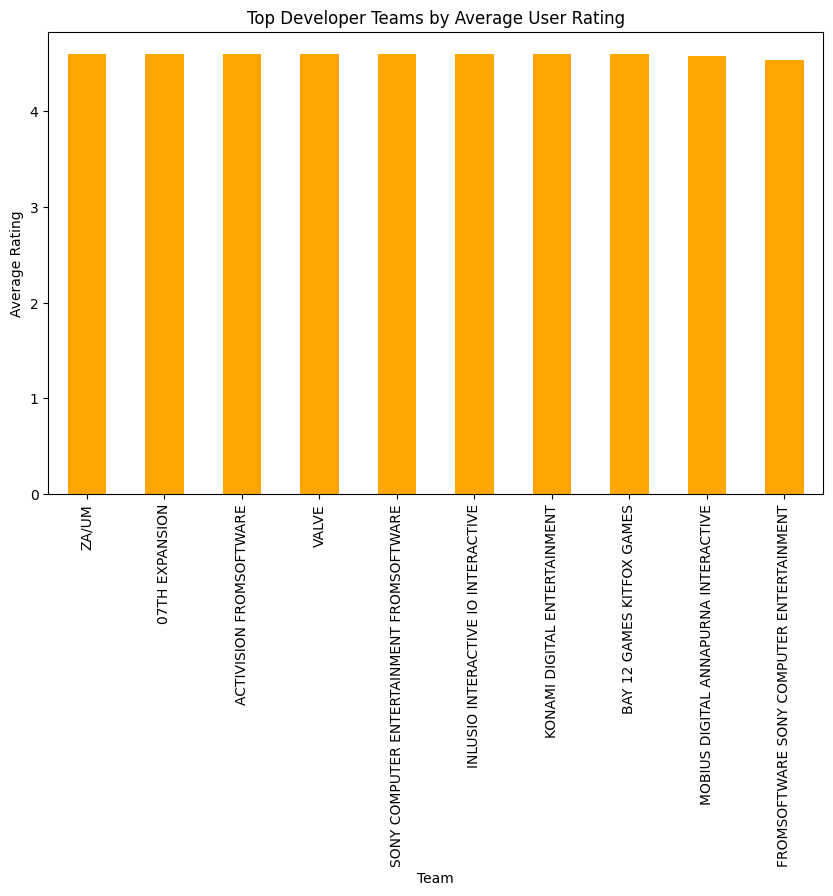

In [96]:
dev_avgs = R_Game_Data.groupby('Team')['Rating'].mean().sort_values(ascending=False).head(10)
dev_avgs.plot(kind='bar', figsize=(10,6), color='orange')
plt.ylabel('Average Rating')
plt.title('Top Developer Teams by Average User Rating')
plt.show()

🎮 Top 10 Developers/Teams by Average Rating:

                                         Team  Rating
762                                     ZA/UM   4.600
0                              07TH EXPANSION   4.600
27                    ACTIVISION FROMSOFTWARE   4.600
723                                     VALVE   4.600
588  SONY COMPUTER ENTERTAINMENT FROMSOFTWARE   4.600
296        INLUSIO INTERACTIVE IO INTERACTIVE   4.600
330              KONAMI DIGITAL ENTERTAINMENT   4.600
89                  BAY 12 GAMES KITFOX GAMES   4.600
376      MOBIUS DIGITAL ANNAPURNA INTERACTIVE   4.575
244  FROMSOFTWARE SONY COMPUTER ENTERTAINMENT   4.540


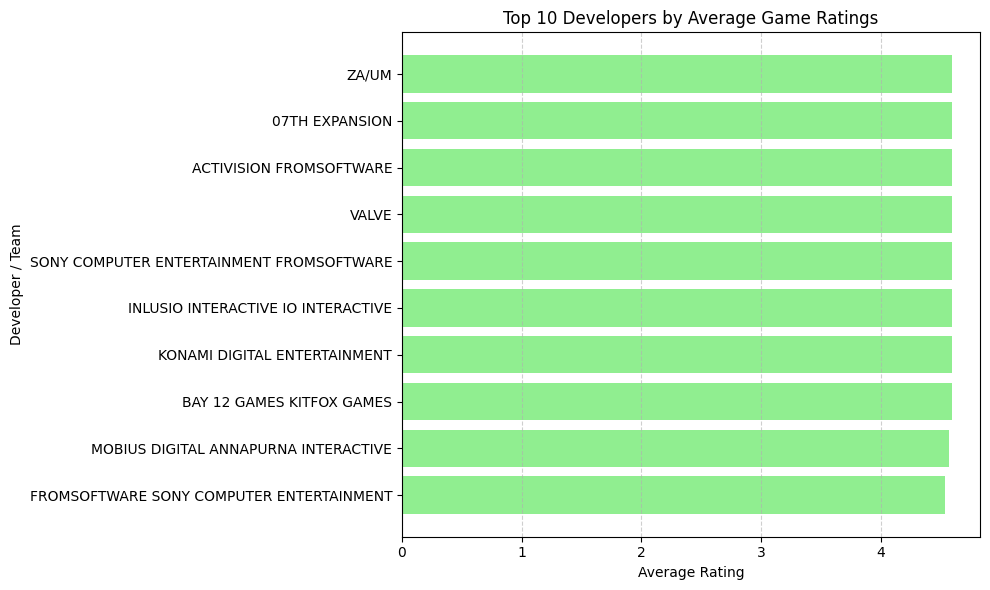

In [97]:
top_developers = (R_Game_Data.groupby("Team")["Rating"]
    .mean()                      # Calculate average rating per team
    .reset_index()               # Convert result back to a DataFrame
    .sort_values(by="Rating", ascending=False)  # Sort by average rating
    .head(10)                    # Get top 10 teams
)

# Display top developers
print("🎮 Top 10 Developers/Teams by Average Rating:\n")
print(top_developers)

# Visualize the result
plt.figure(figsize=(10,6))
plt.barh(top_developers["Team"], top_developers["Rating"], color='lightgreen')
plt.xlabel("Average Rating")
plt.ylabel("Developer / Team")
plt.title("Top 10 Developers by Average Game Ratings")
plt.gca().invert_yaxis()  # Highest rating on top
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

🏆 Top 10 Developers with Highest Average Ratings:

                                                 Team  Average Rating  \
762                                             ZA/UM        4.600000   
376              MOBIUS DIGITAL ANNAPURNA INTERACTIVE        4.575000   
244          FROMSOFTWARE SONY COMPUTER ENTERTAINMENT        4.540000   
327        KONAMI COMPUTER ENTERTAINMENT JAPAN KONAMI        4.500000   
666                                TEAM SILENT KONAMI        4.500000   
628                         SQUARE ENIX PLATINUMGAMES        4.466667   
659                                       TEAM CHERRY        4.440000   
118                     BUENA VISTA GAMES SQUARE ENIX        4.433333   
239                           FROMSOFTWARE ACTIVISION        4.400000   
593  SONY COMPUTER ENTERTAINMENT INC. (SCEI) TEAM ICO        4.400000   

     Number of Games  
762                6  
376                4  
244                5  
327                5  
666                4  
628    

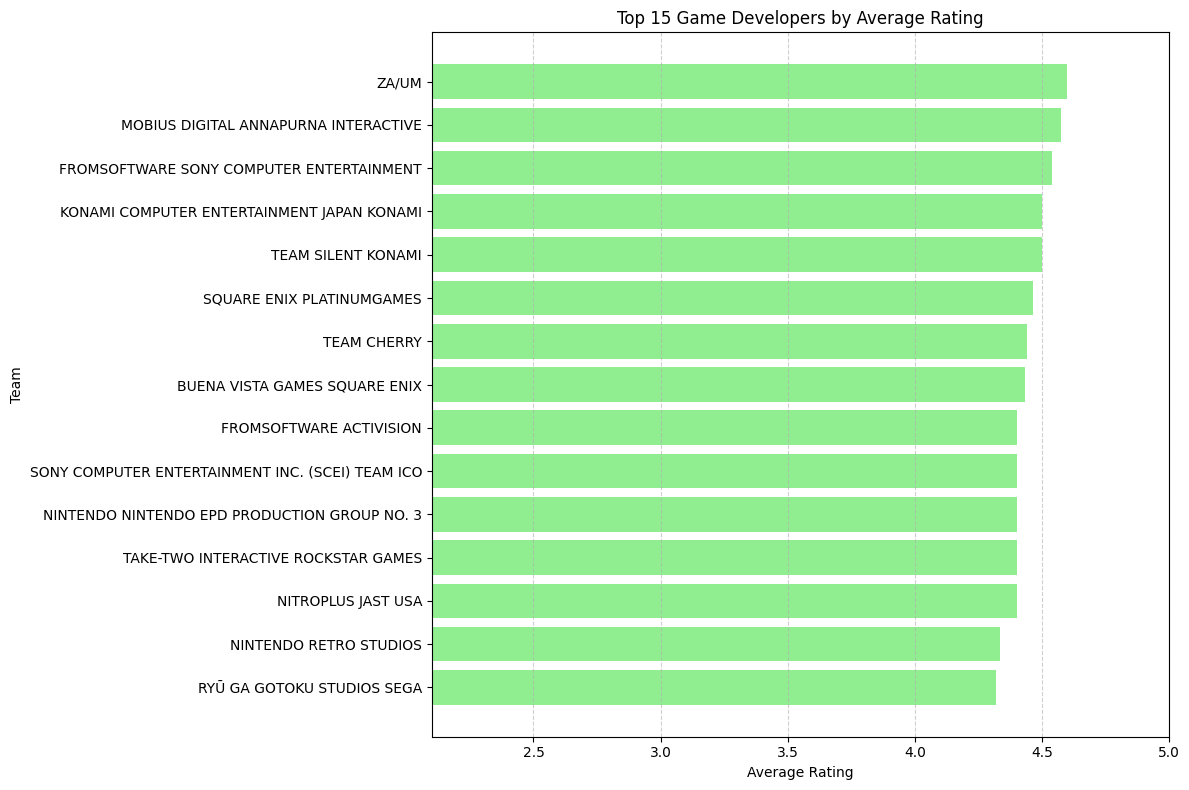

In [98]:
# Calculate average rating by developer
developer_ratings = R_Game_Data.groupby('Team')['Rating'].agg(['mean', 'count']).reset_index()

# Rename columns for clarity
developer_ratings.columns = ['Team', 'Average Rating', 'Number of Games']

# Filter developers with at least 3 games (optional, to avoid developers with just 1-2 games)
min_games = 3
filtered_developers = developer_ratings[developer_ratings['Number of Games'] >= min_games]

# Sort by average rating in descending order
top_developers = filtered_developers.sort_values(by='Average Rating', ascending=False)

# Display top 10 developers with highest average ratings
print("🏆 Top 10 Developers with Highest Average Ratings:\n")
print(top_developers.head(10))

# Create a visualization
plt.figure(figsize=(12, 8))
plt.barh(top_developers['Team'].head(15), top_developers['Average Rating'].head(15), color='lightgreen')
plt.xlabel('Average Rating')
plt.ylabel('Team')
plt.title('Top 15 Game Developers by Average Rating')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.xlim(top_developers['Average Rating'].min() - 0.5, 5.0)  # Assuming ratings are on a 5-point scale
plt.gca().invert_yaxis()  # Highest rating on top
plt.tight_layout()
plt.show()